# Producto Aplicado 2 — Pipeline de IA para predicción y segmentación

**Caso de estudio:** Customer Support Tickets  
**Objetivo:**  Evaluar la implementación e interpretación de modelos de aprendizaje automático aplicados a datos organizacionales.

## 1. Librerías y configuración

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, silhouette_score
)

plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
print("Librerías cargadas correctamente.") # Confirma la carga de librerías esenciales.

Librerías cargadas correctamente.


## 2. ETL — Extract: carga del dataset

In [37]:
FILE_PATH = "Customer support tickets.csv"

# Verifica la existencia del archivo y solicita carga manual si no se encuentra.
if not os.path.exists(FILE_PATH):
    try:
        from google.colab import files
        print("Selecciona el archivo CSV del caso de estudio.")
        uploaded = files.upload()
        FILE_PATH = next(iter(uploaded))
    except ImportError:
        raise FileNotFoundError(
            "No se encontró el CSV. Coloca 'Customer support tickets.csv' en el entorno de ejecución."
        )

df = pd.read_csv(FILE_PATH) # Carga el archivo CSV en un DataFrame de Pandas.
print(f"Archivo: {FILE_PATH}")
print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
display(df.head()) # Muestra las primeras 5 filas del DataFrame.

Archivo: Customer support tickets.csv
Filas: 8,469
Columnas: 17


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 3. Exploratory Data  Analysis (EDA) inicial y calidad de datos

Revision de dimensiones, tipos, valores faltantes y duplicados. Esto permite detectar problemas que podrían afectar el entrenamiento.

In [38]:
print("Dimensiones:", df.shape) # Imprime las dimensiones del DataFrame.
print("\nValores nulos:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing")) # Muestra el conteo de valores nulos por columna.
print("Filas duplicadas:", df.duplicated().sum()) # Imprime el número de filas duplicadas.
print("\nDistribución del objetivo:")
display(df["Ticket Priority"].value_counts().to_frame("tickets")) # Muestra la distribución de la variable objetivo.

Dimensiones: (8469, 17)

Valores nulos:


,missing
Customer Satisfaction Rating,5700
Resolution,5700
Time to Resolution,5700
First Response Time,2819
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Ticket Subject,0


Filas duplicadas: 0

Distribución del objetivo:


,tickets
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063


**Interpretación:** la variable objetivo tiene cuatro clases de prioridad. La distribución es relativamente equilibrada, por lo que la línea base de clase mayoritaria sirve como referencia mínima, pero no es suficiente para evaluar por sí sola un modelo multicategoría.

## 4. ETL — Proceso de limpieza y transformación de datos.

In [39]:
df_clean = df.drop_duplicates().copy() # Elimina filas duplicadas del DataFrame.
df_clean["Date of Purchase"] = pd.to_datetime(df_clean["Date of Purchase"], errors="coerce") # Convierte la columna 'Date of Purchase' a formato de fecha y hora, forzando errores.
df_clean["Customer Satisfaction Rating"] = pd.to_numeric(
    df_clean["Customer Satisfaction Rating"], errors="coerce"
) # Convierte la columna 'Customer Satisfaction Rating' a formato numérico, forzando errores.

# Extrae el año y el mes de la columna 'Date of Purchase'.
df_clean["Purchase Year"] = df_clean["Date of Purchase"].dt.year
df_clean["Purchase Month"] = df_clean["Date of Purchase"].dt.month

print(f"Duplicados eliminados: {len(df)-len(df_clean):,}") # Imprime el número de duplicados eliminados.
print(f"Filas después del ETL: {len(df_clean):,}") # Imprime el número de filas después del proceso ETL.

Duplicados eliminados: 0
Filas después del ETL: 8,469


## 5. EDA orientado al modelado

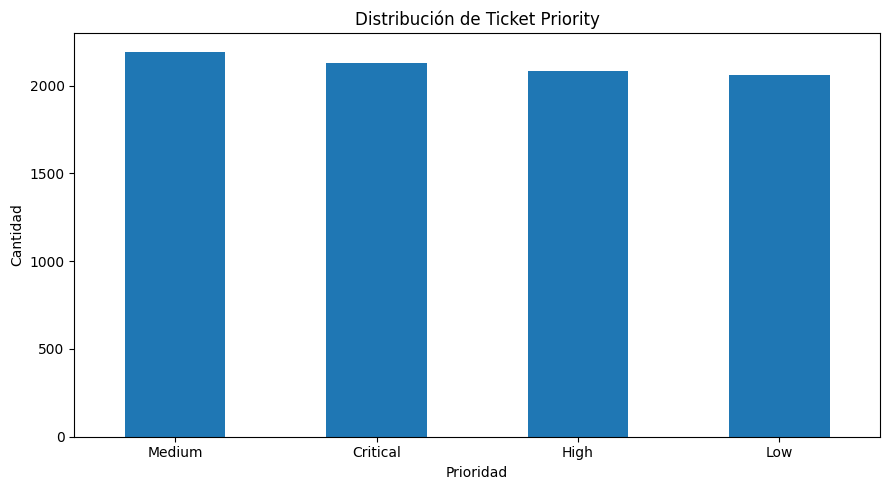

In [40]:
fig, ax = plt.subplots() # Inicializa un gráfico.
df_clean["Ticket Priority"].value_counts().plot(kind="bar", ax=ax) # Grafica la distribución de 'Ticket Priority' como un gráfico de barras.
ax.set_title("Distribución de Ticket Priority") # Establece el título del gráfico.
ax.set_xlabel("Prioridad") # Establece la etiqueta del eje X.
ax.set_ylabel("Cantidad") # Establece la etiqueta del eje Y.
plt.xticks(rotation=0) # Configura la rotación de las etiquetas del eje X.
plt.tight_layout() # Ajusta el diseño del gráfico para evitar superposiciones.
plt.show() # Muestra el gráfico.

**Interpretación:** el gráfico permite comprobar si existe una clase dominante. En este dataset las cuatro prioridades presentan volúmenes cercanos, por lo que una métrica como F1 macro resulta útil para no ocultar diferencias entre clases. **Decisión:** se reportará F1 macro además de accuracy. **Limitación:** el volumen de tickets no indica por sí mismo el costo o impacto operativo de cada prioridad.

## 6. Aprendizaje supervisado — Predicción de prioridad

### 6.1 Definición de variables

El objetivo es predecir `Ticket Priority`. Se excluyen identificadores y campos de texto libre, además de variables que pueden conocerse después de la atención del ticket. Esto evita que el modelo aprenda información que no estaría disponible en el momento real de clasificación.

In [41]:
target = "Ticket Priority" # Define la variable objetivo.

feature_cols = [
    "Customer Age", "Customer Gender", "Product Purchased",
    "Ticket Type", "Ticket Channel", "Purchase Year", "Purchase Month"
] # Define las columnas de características.

X = df_clean[feature_cols].copy() # Crea el conjunto de características (X).
y = df_clean[target].copy() # Crea el vector objetivo (y).

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
) # Divide los datos en conjuntos de entrenamiento y prueba.

num_features = ["Customer Age", "Purchase Year", "Purchase Month"] # Define características numéricas.
cat_features = ["Customer Gender", "Product Purchased", "Ticket Type", "Ticket Channel"] # Define características categóricas.

preprocessor = ColumnTransformer([ # Crea un preprocesador para características numéricas y categóricas.
    ("num", SimpleImputer(strategy="median"), num_features), # Imputación numérica con la mediana.
    ("cat", Pipeline([ # Imputación categórica con la moda y One-Hot Encoding.
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_features)
])

print(f"Entrenamiento: {len(X_train):,} registros") # Imprime el tamaño del conjunto de entrenamiento.
print(f"Prueba: {len(X_test):,} registros") # Imprime el tamaño del conjunto de prueba.

Entrenamiento: 6,775 registros
Prueba: 1,694 registros


### 6.2 Modelo de referencia (Línea base)

Se utiliza `DummyClassifier` con estrategia de clase más frecuente. Esta línea base representa el resultado de una estrategia que ignora las características del ticket y siempre predice la clase predominante.

In [42]:
baseline = Pipeline([ # Define un pipeline para el modelo de línea base.
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent")) # Clasificador dummy que predice la clase más frecuente.
])
baseline.fit(X_train, y_train) # Entrena el modelo de línea base.
baseline_pred = baseline.predict(X_test) # Realiza predicciones en el conjunto de prueba.

baseline_accuracy = accuracy_score(y_test, baseline_pred) # Calcula la exactitud (accuracy) de la línea base.
baseline_f1 = f1_score(y_test, baseline_pred, average="macro") # Calcula la métrica F1 macro de la línea base.

print(f"Baseline accuracy: {baseline_accuracy:.4f}") # Imprime la exactitud de la línea base.
print(f"Baseline F1 macro: {baseline_f1:.4f}") # Imprime la métrica F1 macro de la línea base.

Baseline accuracy: 0.2586
Baseline F1 macro: 0.1027


**Interpretación:** la línea base establece el punto de comparación mínimo. **Decisión:** un modelo de árbol solo aporta valor predictivo si supera esta referencia de forma consistente. **Limitación:** esta línea base no representa una política operativa real; únicamente sirve como benchmark sencillo.

### 6.3 Entrenando Árbol de decisión

Se utiliza un árbol con profundidad limitada para mantener una estructura interpretable. `class_weight="balanced"` evita que una diferencia moderada entre clases domine el entrenamiento.

In [43]:
tree_model = Pipeline([ # Define un pipeline para el modelo de Árbol de Decisión.
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6, random_state=RANDOM_STATE, class_weight="balanced"
    )) # Árbol de Decisión con profundidad limitada y pesos de clase balanceados.
])

tree_model.fit(X_train, y_train) # Entrena el modelo de Árbol de Decisión.
tree_pred = tree_model.predict(X_test) # Realiza predicciones en el conjunto de prueba.

tree_accuracy = accuracy_score(y_test, tree_pred) # Calcula la exactitud (accuracy) del Árbol de Decisión.
tree_precision = precision_score(y_test, tree_pred, average="macro", zero_division=0) # Calcula la precisión macro del Árbol de Decisión.
tree_recall = recall_score(y_test, tree_pred, average="macro", zero_division=0) # Calcula el recall macro del Árbol de Decisión.
tree_f1 = f1_score(y_test, tree_pred, average="macro", zero_division=0) # Calcula la métrica F1 macro del Árbol de Decisión.

print(f"Accuracy: {tree_accuracy:.4f}") # Imprime la exactitud del Árbol de Decisión.
print(f"Precision macro: {tree_precision:.4f}") # Imprime la precisión macro del Árbol de Decisión.
print(f"Recall macro: {tree_recall:.4f}") # Imprime el recall macro del Árbol de Decisión.
print(f"F1 macro: {tree_f1:.4f}") # Imprime la métrica F1 macro del Árbol de Decisión.
print("\nReporte de clasificación:")
print(classification_report(y_test, tree_pred, zero_division=0)) # Imprime el reporte de clasificación detallado.

Accuracy: 0.2550
Precision macro: 0.2502
Recall macro: 0.2505
F1 macro: 0.1875

Reporte de clasificación:
              precision    recall  f1-score   support

    Critical       0.25      0.48      0.33       426
        High       0.20      0.02      0.04       417
         Low       0.29      0.03      0.05       413
      Medium       0.26      0.47      0.33       438

    accuracy                           0.26      1694
   macro avg       0.25      0.25      0.19      1694
weighted avg       0.25      0.26      0.19      1694



**Interpretación:** las métricas muestran el rendimiento del árbol en datos no utilizados durante el entrenamiento. **Decisión:** accuracy permite observar el acierto global, mientras F1 macro ayuda a revisar las cuatro prioridades sin dar más peso a una clase por su volumen. **Limitación:** el desempeño depende de las variables disponibles; no se incorporó el texto del ticket mediante NLP, por lo que parte de la información semántica queda fuera.

### 6.4 Comparación contra la línea base

,Modelo,Accuracy,F1 macro
0,Línea base,0.2586,0.1027
1,Árbol de decisión,0.2550,0.1875


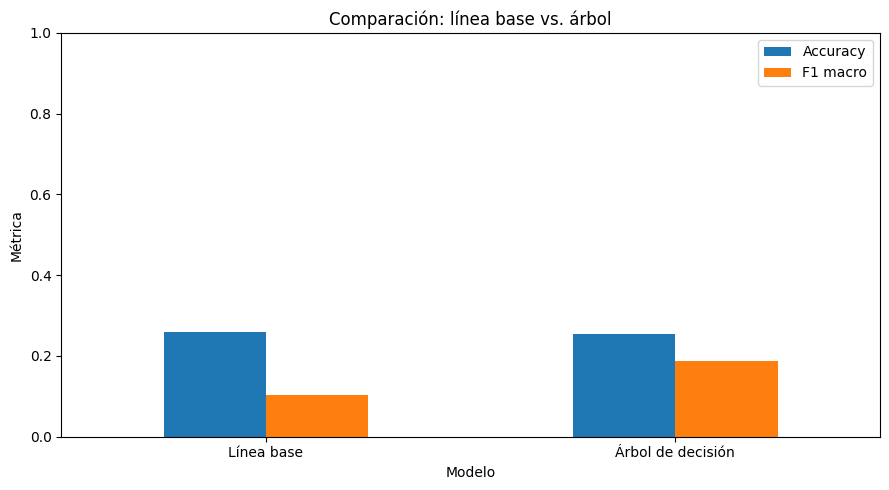

Cambio de accuracy: -0.0035
Cambio de F1 macro: +0.0848


In [44]:
comparison = pd.DataFrame({ # Crea un DataFrame para comparar modelos.
    "Modelo": ["Línea base", "Árbol de decisión"],
    "Accuracy": [baseline_accuracy, tree_accuracy],
    "F1 macro": [baseline_f1, tree_f1]
})
display(comparison.round(4)) # Muestra la tabla de comparación.

ax = comparison.set_index("Modelo")[["Accuracy", "F1 macro"]].plot(kind="bar") # Grafica la exactitud y F1 macro para comparación.
ax.set_ylim(0, 1) # Establece los límites del eje Y.
ax.set_title("Comparación: línea base vs. árbol") # Establece el título del gráfico.
ax.set_ylabel("Métrica") # Establece la etiqueta del eje Y.
plt.xticks(rotation=0) # Configura la rotación de las etiquetas del eje X.
plt.tight_layout() # Ajusta el diseño del gráfico.
plt.show() # Muestra el gráfico.

print(f"Cambio de accuracy: {tree_accuracy-baseline_accuracy:+.4f}") # Imprime el cambio en la exactitud.
print(f"Cambio de F1 macro: {tree_f1-baseline_f1:+.4f}") # Imprime el cambio en la métrica F1 macro.

**Interpretación:** la comparación responde directamente a la pregunta de si el árbol aprende patrones útiles más allá de la clase mayoritaria. **Decisión:** si el modelo no mejora la línea base, no hay evidencia suficiente para utilizarlo como clasificador automático con estas variables. **Limitación:** una sola partición train/test no sustituye validación cruzada ni pruebas con datos de producción.

### 6.5 Matriz de confusión

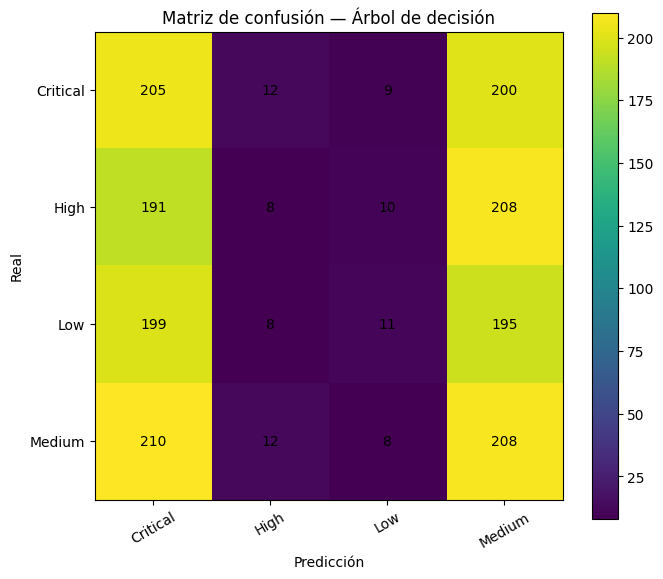

,precision,recall,f1-score,support
Critical,0.255,0.481,0.333,426.000
High,0.200,0.019,0.035,417.000
Low,0.289,0.027,0.049,413.000
Medium,0.256,0.475,0.333,438.000
accuracy,0.255,0.255,0.255,0.255
macro avg,0.250,0.250,0.187,1694.000
weighted avg,0.250,0.255,0.190,1694.000


In [45]:
labels = sorted(y_test.unique()) # Obtiene las etiquetas únicas y ordenadas del conjunto de prueba.
cm = confusion_matrix(y_test, tree_pred, labels=labels) # Calcula la matriz de confusión.

fig, ax = plt.subplots(figsize=(7, 6)) # Inicializa un gráfico.
im = ax.imshow(cm) # Muestra la matriz de confusión como una imagen.
ax.set_title("Matriz de confusión — Árbol de decisión") # Establece el título del gráfico.
ax.set_xlabel("Predicción") # Establece la etiqueta del eje X.
ax.set_ylabel("Real") # Establece la etiqueta del eje Y.
ax.set_xticks(range(len(labels)), labels=labels, rotation=30) # Configura las marcas y etiquetas del eje X.
ax.set_yticks(range(len(labels)), labels=labels) # Configura las marcas y etiquetas del eje Y.
for i in range(len(labels)): # Itera a través de las filas de la matriz.
    for j in range(len(labels)): # Itera a través de las columnas de la matriz.
        ax.text(j, i, cm[i, j], ha="center", va="center") # Añade los valores de la matriz como texto en las celdas.
fig.colorbar(im, ax=ax) # Añade una barra de color al gráfico.
plt.tight_layout() # Ajusta el diseño del gráfico.
plt.show() # Muestra el gráfico.

report = pd.DataFrame(classification_report(y_test, tree_pred, output_dict=True, zero_division=0)).T # Genera y formatea el reporte de clasificación.
display(report.round(3)) # Muestra el reporte de clasificación.

**Interpretación:** la matriz muestra qué prioridades se confunden entre sí. **Decisión:** si las clases de mayor impacto tienen recall bajo, el modelo no debería utilizarse para asignación automática sin controles adicionales. **Limitación:** la matriz depende del conjunto de prueba y no mide costos diferentes entre errores; confundir una prioridad crítica puede tener consecuencias distintas a confundir dos prioridades no críticas.

### 6.6 Visualización del árbol

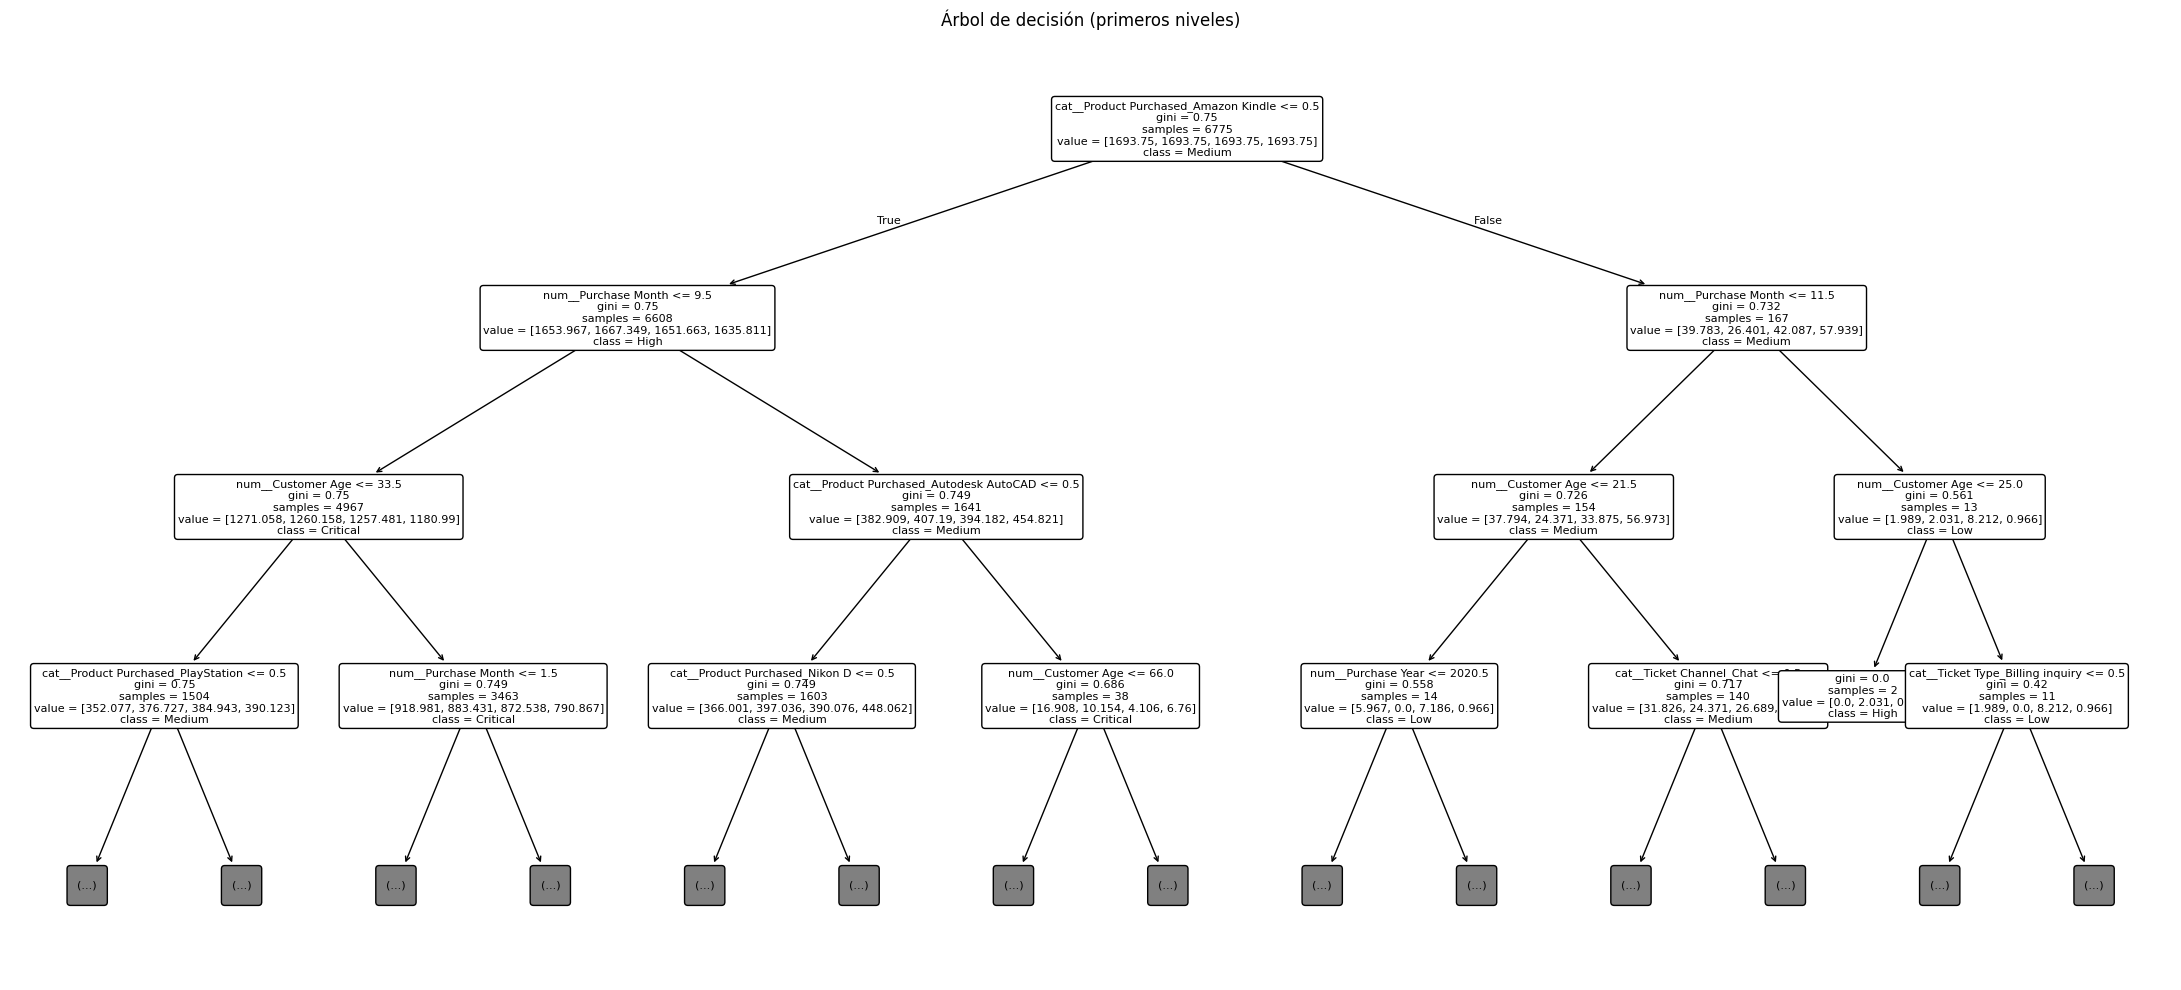

In [46]:
# Transforma el conjunto de entrenamiento para obtener los nombres de las características.
X_train_transformed = tree_model.named_steps["preprocessor"].transform(X_train) # Transforma los datos de entrenamiento.
feature_names = tree_model.named_steps["preprocessor"].get_feature_names_out() # Obtiene los nombres de las características después del preprocesamiento.

tree = tree_model.named_steps["model"] # Extrae el modelo de Árbol de Decisión.

fig, ax = plt.subplots(figsize=(22, 10)) # Inicializa un gráfico.
plot_tree(
    tree, feature_names=feature_names, class_names=tree.classes_,
    filled=False, rounded=True, fontsize=8, max_depth=3, ax=ax
) # Grafica el Árbol de Decisión.
ax.set_title("Árbol de decisión (primeros niveles)") # Establece el título del gráfico.
plt.tight_layout() # Ajusta el diseño del gráfico.
plt.show() # Muestra el gráfico.

**Interpretación:** los primeros niveles muestran las variables y reglas que el árbol utiliza para separar las clases. **Decisión:** estas reglas pueden servir para identificar qué características aportan información al proceso de clasificación. **Limitación:** mostrar solo los primeros niveles facilita la lectura, pero no representa todas las reglas del árbol completo.

## 7. Segmentación no supervisada — K-Means

Para la segmentación se construye un perfil operativo de los tickets usando edad del cliente, hora de primera respuesta, hora de resolución y satisfacción. Los campos de tiempo del dataset representan marcas horarias, por lo que se transforman a horas decimales. Los valores faltantes se imputan con la mediana. Esta segmentación es **descriptiva**, no predictiva.

In [47]:
seg = df_clean.copy() # Crea una copia del DataFrame limpio para la segmentación.

for col in ["First Response Time", "Time to Resolution"]: # Itera sobre las columnas de tiempo.
    parsed = pd.to_datetime(seg[col], errors="coerce") # Convierte la columna a tipo datetime.
    seg[col + " Hour"] = parsed.dt.hour + parsed.dt.minute / 60 + parsed.dt.second / 3600 # Extrae y calcula la hora decimal.

seg_features = [
    "Customer Age", "First Response Time Hour",
    "Time to Resolution Hour", "Customer Satisfaction Rating"
] # Define las características para la segmentación.
Z = seg[seg_features].copy() # Crea la matriz de características (Z) para clustering.
Z = Z.fillna(Z.median(numeric_only=True)) # Imputa los valores faltantes con la mediana.

scaler = StandardScaler() # Inicializa el escalador de características.
Z_scaled = scaler.fit_transform(Z) # Escala la matriz de características.

silhouette_by_k = {} # Diccionario para almacenar los scores de silueta por k.
models_by_k = {} # Diccionario para almacenar los modelos KMeans por k.
for k in range(2, 7): # Itera a través de los valores de k de 2 a 6.
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10) # Inicializa el modelo KMeans.
    labels_k = km.fit_predict(Z_scaled) # Entrena KMeans y predice las etiquetas de clúster.
    silhouette_by_k[k] = silhouette_score(Z_scaled, labels_k) # Calcula y almacena el score de silueta.
    models_by_k[k] = km # Almacena el modelo KMeans.

silhouette_table = pd.DataFrame({ # Crea un DataFrame para los scores de silueta.
    "k": list(silhouette_by_k.keys()),
    "Silhouette": list(silhouette_by_k.values())
})
display(silhouette_table.round(4)) # Muestra la tabla de scores de silueta.

best_k = max(silhouette_by_k, key=silhouette_by_k.get) # Selecciona el k con el score de silueta más alto.
best_km = models_by_k[best_k] # Recupera el mejor modelo KMeans.
seg["Segment"] = best_km.labels_ # Asigna las etiquetas de clúster al DataFrame.
print(f"k seleccionado por mayor silhouette: {best_k}") # Imprime el valor de k seleccionado.

,k,Silhouette
0,2,0.2414
1,3,0.2606
2,4,0.2687
3,5,0.2931
4,6,0.3135


k seleccionado por mayor silhouette: 6


**Interpretación:** el silhouette score evalúa qué tan separados y cohesionados están los grupos. **Decisión:** se selecciona el valor de `k` con mayor silhouette dentro del rango evaluado. **Limitación:** el silhouette no demuestra por sí solo que los segmentos sean útiles para el negocio; también deben ser interpretables y accionables.

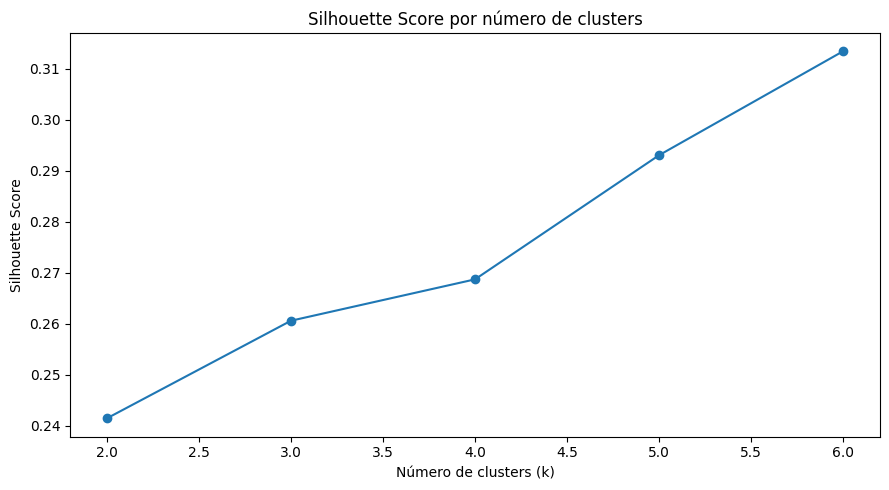

In [48]:
ax = silhouette_table.plot(x="k", y="Silhouette", marker="o", legend=False) # Grafica el score de silueta por número de clusters.
ax.set_title("Silhouette Score por número de clusters") # Establece el título del gráfico.
ax.set_xlabel("Número de clusters (k)") # Establece la etiqueta del eje X.
ax.set_ylabel("Silhouette Score") # Establece la etiqueta del eje Y.
plt.tight_layout() # Ajusta el diseño del gráfico.
plt.show() # Muestra el gráfico.

### 7.1 Perfil de los segmentos

In [49]:
profile = seg.groupby("Segment")[seg_features].mean().round(2) # Calcula el promedio de las características de segmentación por segmento.
profile["Tickets"] = seg["Segment"].value_counts().sort_index() # Añade el conteo de tickets por segmento.
display(profile.sort_index()) # Muestra el perfil de los segmentos.

,Customer Age,First Response Time Hour,Time to Resolution Hour,Customer Satisfaction Rating,Tickets
Segment,,,,,
0,30.06,8.43,9.15,2.45,2747
1,45.62,20.09,8.06,2.35,1363
2,57.54,7.72,8.95,2.47,2698
3,43.99,12.16,17.74,1.37,537
4,45.06,12.14,19.19,4.21,577
5,42.48,10.69,5.35,4.46,547


**Interpretación:** el perfil permite describir las diferencias promedio entre segmentos. **Decisión:** los grupos pueden utilizarse para diseñar acciones diferenciadas de soporte, por ejemplo, priorizar análisis de satisfacción o revisar tiempos de atención. **Limitación:** un segmento estadístico no representa necesariamente una causa de comportamiento; se requieren validaciones de negocio antes de convertirlo en una regla operativa.

### 7.2 Visualización 2D mediante PCA

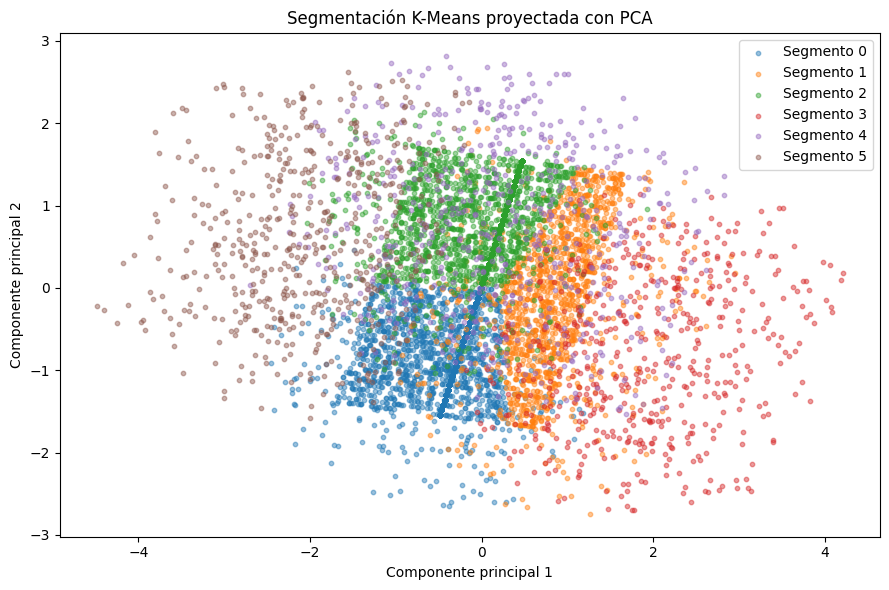

Varianza explicada por PCA: [0.263 0.25 ]


In [50]:
pca = PCA(n_components=2, random_state=RANDOM_STATE) # Inicializa PCA con 2 componentes.
Z_pca = pca.fit_transform(Z_scaled) # Ajusta PCA y transforma los datos escalados.

fig, ax = plt.subplots(figsize=(9, 6)) # Inicializa un gráfico.
for cluster in sorted(seg["Segment"].unique()): # Itera a través de los clusters únicos.
    mask = seg["Segment"] == cluster # Crea una máscara para el clúster actual.
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1], s=10, alpha=0.45, label=f"Segmento {cluster}") # Grafica los puntos de datos para cada clúster.
ax.set_title("Segmentación K-Means proyectada con PCA") # Establece el título del gráfico.
ax.set_xlabel("Componente principal 1") # Establece la etiqueta del eje X.
ax.set_ylabel("Componente principal 2") # Establece la etiqueta del eje Y.
ax.legend() # Muestra la leyenda.
plt.tight_layout() # Ajusta el diseño del gráfico.
plt.show() # Muestra el gráfico.

print("Varianza explicada por PCA:", np.round(pca.explained_variance_ratio_, 3)) # Imprime la varianza explicada por PCA.

**Interpretación:** PCA permite visualizar en dos dimensiones una estructura que originalmente tiene cuatro variables. **Decisión:** la visualización ayuda a revisar si los grupos tienen separación visual razonable y facilita su comunicación. **Limitación:** la proyección pierde información, por lo que la visualización no reemplaza el silhouette score ni el análisis de perfiles.

In [51]:
critical_recall = report.loc["Critical", "recall"] if "Critical" in report.index else np.nan # Extrae el recall para la prioridad 'Critical'.

print("RESUMEN PARA EL JUICIO PROFESIONAL") # Imprime el encabezado del resumen.
print(f"Accuracy baseline: {baseline_accuracy:.4f}") # Imprime la exactitud de la línea base.
print(f"Accuracy árbol:    {tree_accuracy:.4f}") # Imprime la exactitud del Árbol de Decisión.
print(f"F1 macro baseline: {baseline_f1:.4f}") # Imprime la métrica F1 macro de la línea base.
print(f"F1 macro árbol:    {tree_f1:.4f}") # Imprime la métrica F1 macro del Árbol de Decisión.
print(f"Silhouette seleccionado (k={best_k}): {silhouette_by_k[best_k]:.4f}") # Imprime el score de silueta seleccionado.
if not np.isnan(critical_recall):
    print(f"Recall Critical:    {critical_recall:.4f}") # Imprime el recall para la prioridad 'Critical' si está disponible.

if tree_accuracy > baseline_accuracy and tree_f1 > baseline_f1: # Comprueba si el modelo de árbol supera a la línea base.
    verdict = "El árbol supera la línea base en las métricas principales; aun así, se recomienda una validación adicional antes de automatizar decisiones."
else:
    verdict = "El árbol no supera claramente la línea base en las métricas principales; con estas variables no se recomienda automatizar la clasificación."
print("\nConclusión técnica:") # Imprime el encabezado de la conclusión técnica.
print(verdict) # Imprime el veredicto técnico.

RESUMEN PARA EL JUICIO PROFESIONAL
Accuracy baseline: 0.2586
Accuracy árbol:    0.2550
F1 macro baseline: 0.1027
F1 macro árbol:    0.1875
Silhouette seleccionado (k=6): 0.3135
Recall Critical:    0.4812

Conclusión técnica:
El árbol no supera claramente la línea base en las métricas principales; con estas variables no se recomienda automatizar la clasificación.


## 8. Archivo de datos depurado

In [52]:
CLEAN_FILE = "customer_support_tickets_depurado.csv" # Define el nombre del archivo depurado.
df_clean.to_csv(CLEAN_FILE, index=False) # Guarda el DataFrame limpio en un archivo CSV.
print(f"Archivo generado: {CLEAN_FILE}") # Imprime el nombre del archivo generado.

Archivo generado: customer_support_tickets_depurado.csv
